# NPS Preditivo: Analise Exploratoria de Dados

Tech Challenge Fase 1 - FIAP Pos Tech AI Scientist

Neste notebook eu analiso os dados operacionais de 2.500 pedidos de um e-commerce para entender o que mais impacta a satisfacao dos clientes, medida pelo NPS. O objetivo e identificar os fatores que explicam quem vira detrator e quem vira promotor, para que a empresa possa agir antes da pesquisa de NPS ser enviada.

A base usada e `desafio_nps_fase_1.csv`, com 19 variaveis cobrindo logistica, atendimento, perfil do cliente e a nota NPS dada ao final da compra. A metodologia segue o CRISP-DM nas etapas de entendimento dos dados e analise exploratoria.

## 1. Importacao de Bibliotecas

Vou usar pandas para manipulacao, matplotlib e seaborn para os graficos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

## 2. Leitura e Visao Geral dos Dados

In [2]:
df = pd.read_csv('../data/raw/desafio_nps_fase_1.csv')

print(f'Dimensoes: {df.shape[0]} linhas x {df.shape[1]} colunas')
print(f'Valores faltantes: {df.isnull().sum().sum()} (base limpa)')
df.head()

Dimensoes: 2500 linhas x 19 colunas
Valores faltantes: 0 (base limpa)


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [3]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.50,721.83,1.00,625.75,1250.50,1875.25,2500.00
customer_age,2500.0,43.40,14.89,18.00,31.00,43.00,56.00,69.00
customer_tenure_months,2500.0,61.32,34.48,1.00,31.00,62.00,91.00,119.00
order_id,2500.0,51250.50,721.83,50001.00,50625.75,51250.50,51875.25,52500.00
order_value,2500.0,434.26,289.77,7.76,220.24,375.52,577.29,1983.81
items_quantity,2500.0,3.47,1.69,1.00,2.00,3.00,5.00,6.00
discount_value,2500.0,29.75,29.23,0.02,8.88,20.94,40.83,230.33
payment_installments,2500.0,6.00,3.16,1.00,3.00,6.00,9.00,11.00
delivery_time_days,2500.0,8.02,3.77,2.00,5.00,8.00,11.00,14.00
delivery_delay_days,2500.0,2.19,1.45,0.00,1.00,2.00,3.00,8.00


## 3. Analise da Variavel Target: nps_score

O `nps_score` e a nota que o cliente da ao final da compra, de 0 a 10. Vou usar a definicao classica do Net Promoter Score:

- Promotores: nota 9 ou 10
- Neutros: nota 7 ou 8
- Detratores: nota 0 a 6

O NPS final e calculado como percentual de promotores menos percentual de detratores.

In [4]:
def categorizar_nps(nota):
    if nota >= 9:
        return 'Promotor'
    elif nota <= 6:
        return 'Detrator'
    else:
        return 'Neutro'

df['nps_categoria'] = df['nps_score'].apply(categorizar_nps)

contagem = df['nps_categoria'].value_counts()
percentual = contagem / len(df) * 100

for cat in ['Promotor', 'Neutro', 'Detrator']:
    print(f'{cat}: {contagem[cat]} ({percentual[cat]:.1f}%)')

pct_p = percentual.get('Promotor', 0)
pct_d = percentual.get('Detrator', 0)
print(f'\nNPS agregado da empresa: {pct_p - pct_d:.1f}')
print(f'Media nps_score: {df["nps_score"].mean():.2f}')
print(f'Mediana nps_score: {df["nps_score"].median():.2f}')

Promotor: 110 (4.4%)
Neutro: 539 (21.6%)
Detrator: 1851 (74.0%)

NPS agregado da empresa: -69.6
Media nps_score: 4.38
Mediana nps_score: 4.40


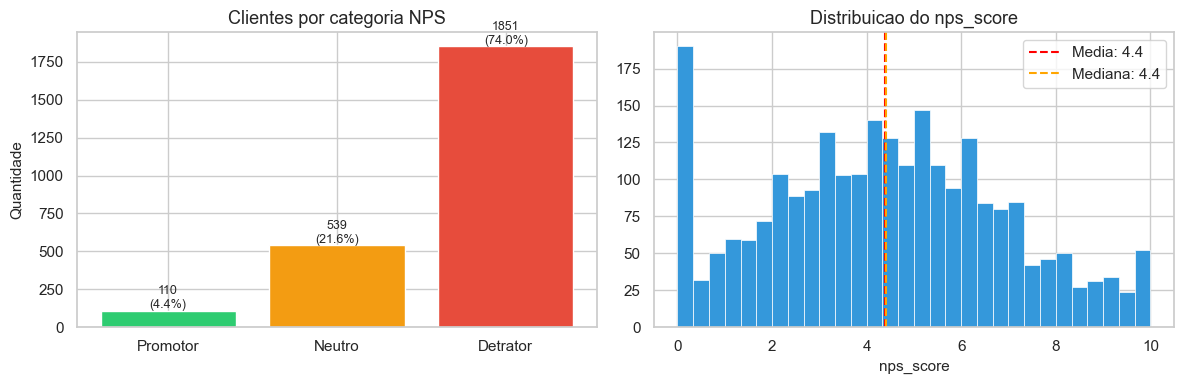

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cores = {'Promotor': '#2ecc71', 'Neutro': '#f39c12', 'Detrator': '#e74c3c'}
ordem = ['Promotor', 'Neutro', 'Detrator']
vals = [contagem[c] for c in ordem]

axes[0].bar(ordem, vals, color=[cores[c] for c in ordem], edgecolor='white')
axes[0].set_title('Clientes por categoria NPS')
axes[0].set_ylabel('Quantidade')
for idx, (cat, val) in enumerate(zip(ordem, vals)):
    axes[0].text(idx, val + 15, f'{val}\n({percentual[cat]:.1f}%)', ha='center', fontsize=9)

axes[1].hist(df['nps_score'], bins=30, color='#3498db', edgecolor='white', linewidth=0.5)
axes[1].axvline(df['nps_score'].mean(), color='red', linestyle='--',
                label=f'Media: {df["nps_score"].mean():.1f}')
axes[1].axvline(df['nps_score'].median(), color='orange', linestyle='--',
                label=f'Mediana: {df["nps_score"].median():.1f}')
axes[1].set_title('Distribuicao do nps_score')
axes[1].set_xlabel('nps_score')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/fig_01_distribuicao_nps.png', bbox_inches='tight', dpi=120)
plt.show()

## 4. Correlacao com o NPS

Calculei a correlacao de Spearman entre cada variavel numerica e o `nps_score`. Spearman e melhor aqui porque nao exige que as relacoes sejam lineares.

In [6]:
variaveis_num = [
    'customer_age', 'customer_tenure_months', 'order_value', 'items_quantity',
    'discount_value', 'payment_installments', 'delivery_time_days',
    'delivery_delay_days', 'freight_value', 'delivery_attempts',
    'customer_service_contacts', 'resolution_time_days',
    'complaints_count', 'repeat_purchase_30d', 'csat_internal_score'
]

corrs = (
    df[variaveis_num + ['nps_score']]
    .corr(method='spearman')['nps_score']
    .drop('nps_score')
    .sort_values()
)

for var, val in corrs.items():
    print(f'{var:35s}: {val:+.3f}')

delivery_delay_days                : -0.586
complaints_count                   : -0.490
customer_service_contacts          : -0.336
resolution_time_days               : -0.190
freight_value                      : -0.040
customer_tenure_months             : -0.012
customer_age                       : -0.007
delivery_time_days                 : +0.000
items_quantity                     : +0.006
discount_value                     : +0.012
delivery_attempts                  : +0.026
payment_installments               : +0.027
order_value                        : +0.036
repeat_purchase_30d                : +0.489
csat_internal_score                : +0.561


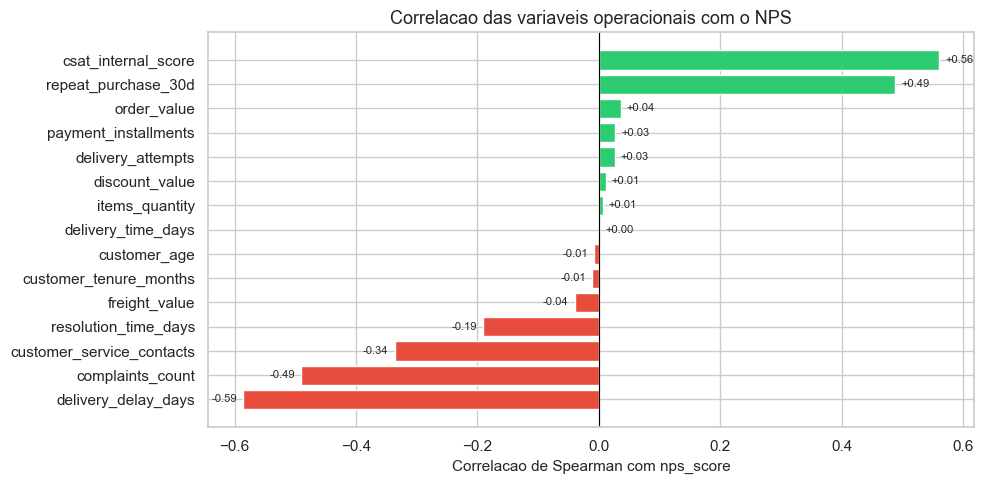

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
cores_barras = ['#e74c3c' if c < 0 else '#2ecc71' for c in corrs.values]
ax.barh(corrs.index, corrs.values, color=cores_barras, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlacao de Spearman com nps_score')
ax.set_title('Correlacao das variaveis operacionais com o NPS')
for idx, (var, val) in enumerate(corrs.items()):
    ax.text(val + (0.01 if val >= 0 else -0.01), idx, f'{val:+.2f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/fig_02_correlacoes_nps.png', bbox_inches='tight', dpi=120)
plt.show()

Principais achados da correlacao:

O atraso na entrega (-0,59) e o fator com maior impacto negativo. O score CSAT interno (+0,56) anda junto com o NPS, e o numero de reclamacoes (-0,49) e contatos com atendimento (-0,34) tambem aparecem como fatores importantes. Um ponto curioso e que o tempo total de entrega tem correlacao quase zero, o que sugere que o problema nao e demorar para entregar, e sim nao cumprir o prazo prometido.

## 5. Analise Bivariada: Fatores Chave vs. NPS

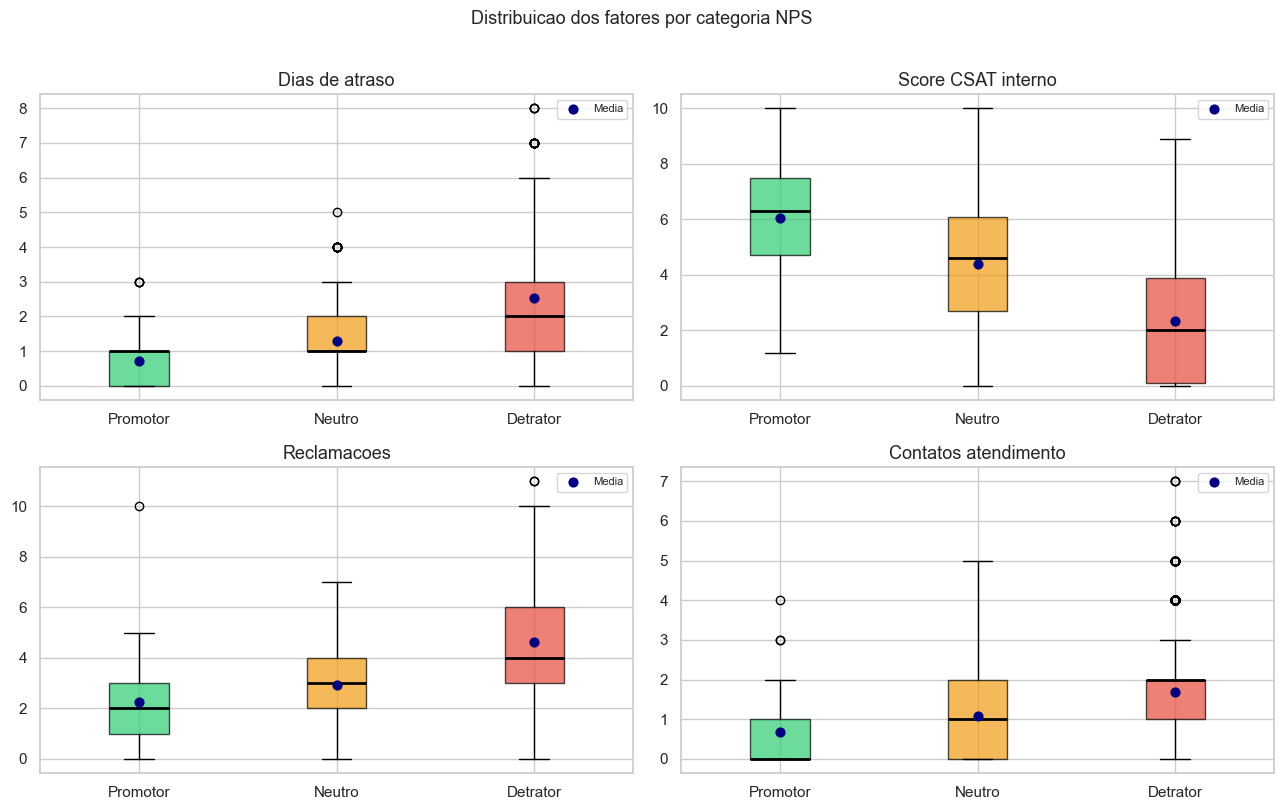

In [8]:
variaveis_chave = ['delivery_delay_days', 'csat_internal_score',
                   'complaints_count', 'customer_service_contacts']
titulos = ['Dias de atraso', 'Score CSAT interno', 'Reclamacoes', 'Contatos atendimento']
ordem_cat = ['Promotor', 'Neutro', 'Detrator']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
cores_box = {'Promotor': '#2ecc71', 'Neutro': '#f39c12', 'Detrator': '#e74c3c'}

for i, (var, titulo) in enumerate(zip(variaveis_chave, titulos)):
    dados = [df[df['nps_categoria'] == cat][var].values for cat in ordem_cat]
    bp = axes[i].boxplot(dados, labels=ordem_cat, patch_artist=True,
                         medianprops={'color': 'black', 'linewidth': 2})
    for patch, cat in zip(bp['boxes'], ordem_cat):
        patch.set_facecolor(cores_box[cat])
        patch.set_alpha(0.7)
    medias = [df[df['nps_categoria'] == cat][var].mean() for cat in ordem_cat]
    axes[i].scatter(range(1, 4), medias, color='navy', zorder=5, s=40, label='Media')
    axes[i].set_title(titulo)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuicao dos fatores por categoria NPS', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/fig_03_boxplots_fatores_nps.png', bbox_inches='tight', dpi=120)
plt.show()

In [9]:
print('Medias por categoria NPS:')
print(df.groupby('nps_categoria')[variaveis_chave + ['resolution_time_days']].mean().round(2).loc[ordem_cat].to_string())

Medias por categoria NPS:
               delivery_delay_days  csat_internal_score  complaints_count  customer_service_contacts  resolution_time_days
nps_categoria                                                                                                             
Promotor                      0.72                 6.04              2.27                       0.67                  3.70
Neutro                        1.29                 4.37              2.91                       1.09                  4.79
Detrator                      2.53                 2.34              4.62                       1.69                  5.79


## 6. Ponto de Ruptura: Atraso na Entrega

In [10]:
def faixa_atraso(d):
    if d == 0: return '0 (no prazo)'
    elif d <= 2: return '1-2 dias'
    elif d <= 5: return '3-5 dias'
    else: return '6+ dias'

df['faixa_atraso'] = df['delivery_delay_days'].apply(faixa_atraso)

ordem_faixa = ['0 (no prazo)', '1-2 dias', '3-5 dias', '6+ dias']
resumo_faixa = df.groupby('faixa_atraso', sort=False).agg(
    n_clientes=('nps_score', 'count'),
    nps_medio=('nps_score', 'mean')
).round(2).reindex(ordem_faixa)

print('NPS medio por faixa de atraso:')
print(resumo_faixa.to_string())

NPS medio por faixa de atraso:
              n_clientes  nps_medio
faixa_atraso                       
0 (no prazo)         277       6.86
1-2 dias            1261       5.05
3-5 dias             911       2.89
6+ dias               51       0.81


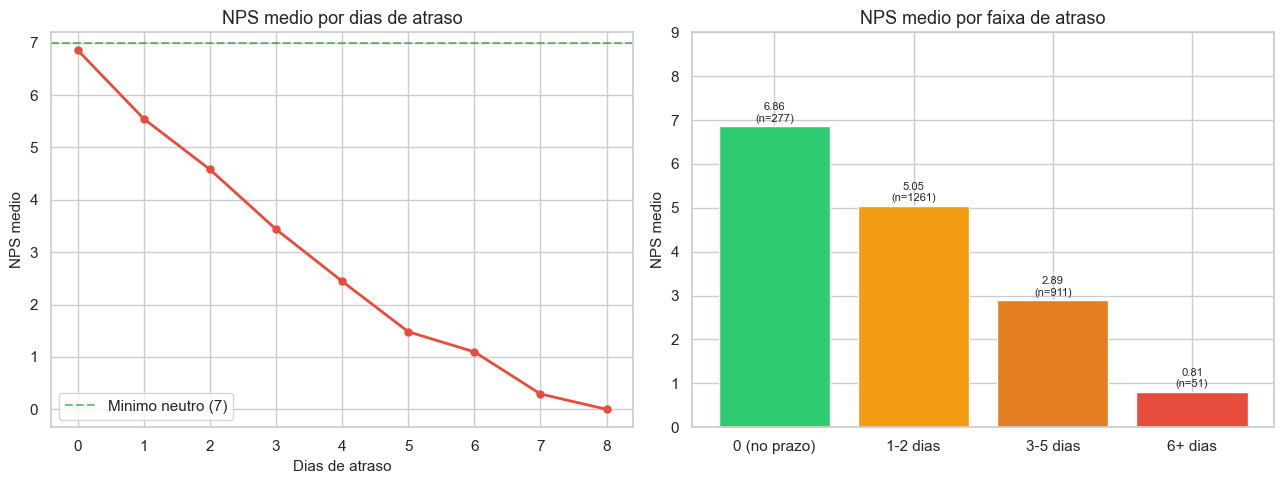

Ponto de ruptura: a partir de 3 dias de atraso, NPS cai de 5.05 para 2.89.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

nps_por_atraso = df.groupby('delivery_delay_days')['nps_score'].mean().reset_index()
axes[0].plot(nps_por_atraso['delivery_delay_days'], nps_por_atraso['nps_score'],
             marker='o', color='#e74c3c', linewidth=2, markersize=5)
axes[0].axhline(7, color='green', linestyle='--', alpha=0.5, label='Minimo neutro (7)')
axes[0].set_xlabel('Dias de atraso')
axes[0].set_ylabel('NPS medio')
axes[0].set_title('NPS medio por dias de atraso')
axes[0].legend()

cores_faixa = ['#2ecc71', '#f39c12', '#e57e22', '#e74c3c']
nps_faixa = [resumo_faixa.loc[f, 'nps_medio'] for f in ordem_faixa]
n_faixa = [resumo_faixa.loc[f, 'n_clientes'] for f in ordem_faixa]

bars = axes[1].bar(ordem_faixa, nps_faixa, color=cores_faixa, edgecolor='white')
axes[1].set_ylabel('NPS medio')
axes[1].set_title('NPS medio por faixa de atraso')
axes[1].set_ylim(0, 9)
for bar, val, n in zip(bars, nps_faixa, n_faixa):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                 f'{val:.2f}\n(n={int(n)})', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/fig_04_ruptura_atraso.png', bbox_inches='tight', dpi=120)
plt.show()
print('Ponto de ruptura: a partir de 3 dias de atraso, NPS cai de 5.05 para 2.89.')

## 7. Impacto dos Contatos com Atendimento

NPS medio por numero de contatos:
                             n  nps_medio
customer_service_contacts                
0                          554       5.54
1                          816       4.66
2                          640       4.12
3                          314       3.20
4                          132       2.65
5                           34       2.24
6                            7       0.74
7                            3       1.20


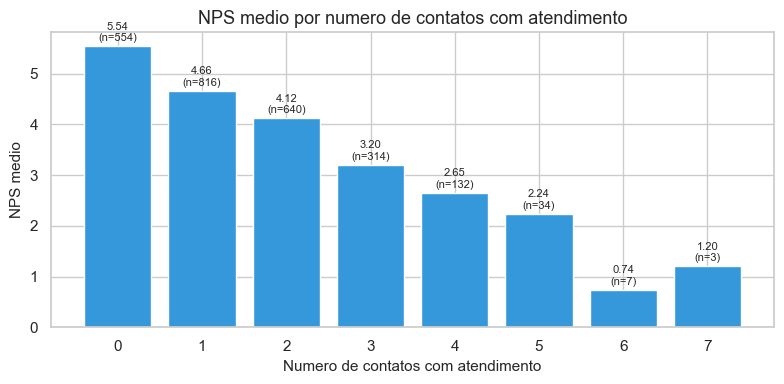

In [12]:
nps_contato = df.groupby('customer_service_contacts').agg(
    n=('nps_score','count'), nps_medio=('nps_score','mean')).round(2)

print('NPS medio por numero de contatos:')
print(nps_contato.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(nps_contato.index, nps_contato['nps_medio'], color='#3498db', edgecolor='white')
ax.set_xlabel('Numero de contatos com atendimento')
ax.set_ylabel('NPS medio')
ax.set_title('NPS medio por numero de contatos com atendimento')
for _, row in nps_contato.iterrows():
    ax.text(row.name, row['nps_medio'] + 0.1,
            f'{row["nps_medio"]:.2f}\n(n={int(row["n"])})', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/fig_05_atendimento_nps.png', bbox_inches='tight', dpi=120)
plt.show()

## 8. Recompra em 30 Dias por Categoria NPS

Taxa de recompra em 30 dias:
  Promotor: 100.0%
  Neutro: 20.0%
  Detrator: 0.0%


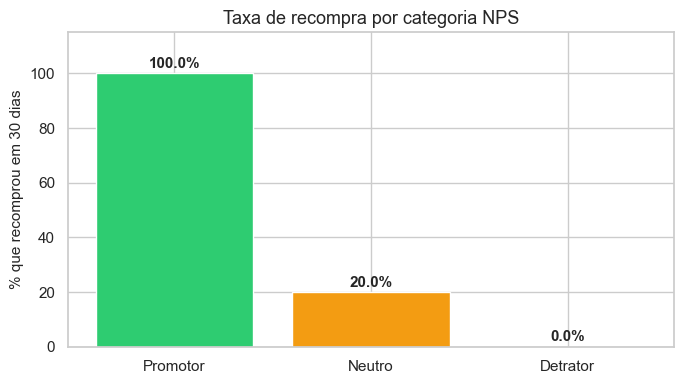

In [13]:
recompra = df.groupby('nps_categoria')['repeat_purchase_30d'].mean() * 100
recompra = recompra.loc[['Promotor', 'Neutro', 'Detrator']]

print('Taxa de recompra em 30 dias:')
for cat, val in recompra.items():
    print(f'  {cat}: {val:.1f}%')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(recompra.index, recompra.values,
              color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
ax.set_ylabel('% que recomprou em 30 dias')
ax.set_title('Taxa de recompra por categoria NPS')
ax.set_ylim(0, 115)
for bar, val in zip(bars, recompra.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_06_recompra_por_nps.png', bbox_inches='tight', dpi=120)
plt.show()

## 9. Analise por Regiao

NPS por regiao:
                   n  nps_medio  pct_detrator
customer_region                              
Centro-Oeste     468       4.21         74.36
Sudeste          520       4.37         74.62
Norte            506       4.38         74.51
Nordeste         485       4.42         74.02
Sul              521       4.49         72.74


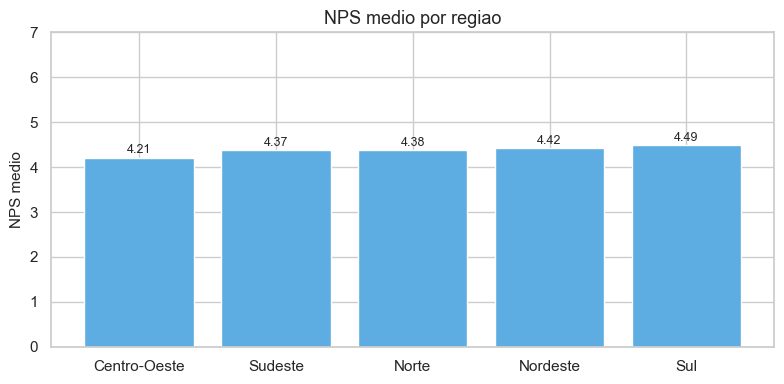

Diferenca entre regioes e pequena. O problema nao parece geografico.


In [14]:
nps_regiao = df.groupby('customer_region').agg(
    n=('nps_score','count'),
    nps_medio=('nps_score','mean'),
    pct_detrator=('nps_categoria', lambda x: (x=='Detrator').mean()*100)
).round(2).sort_values('nps_medio')

print('NPS por regiao:')
print(nps_regiao.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(nps_regiao.index, nps_regiao['nps_medio'], color='#5dade2', edgecolor='white')
ax.set_ylabel('NPS medio')
ax.set_title('NPS medio por regiao')
ax.set_ylim(0, 7)
for i, (reg, val) in enumerate(nps_regiao['nps_medio'].items()):
    ax.text(i, val + 0.1, f'{val:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/fig_07_nps_por_regiao.png', bbox_inches='tight', dpi=120)
plt.show()
print('Diferenca entre regioes e pequena. O problema nao parece geografico.')

## 10. Perfil: Promotores vs. Detratores

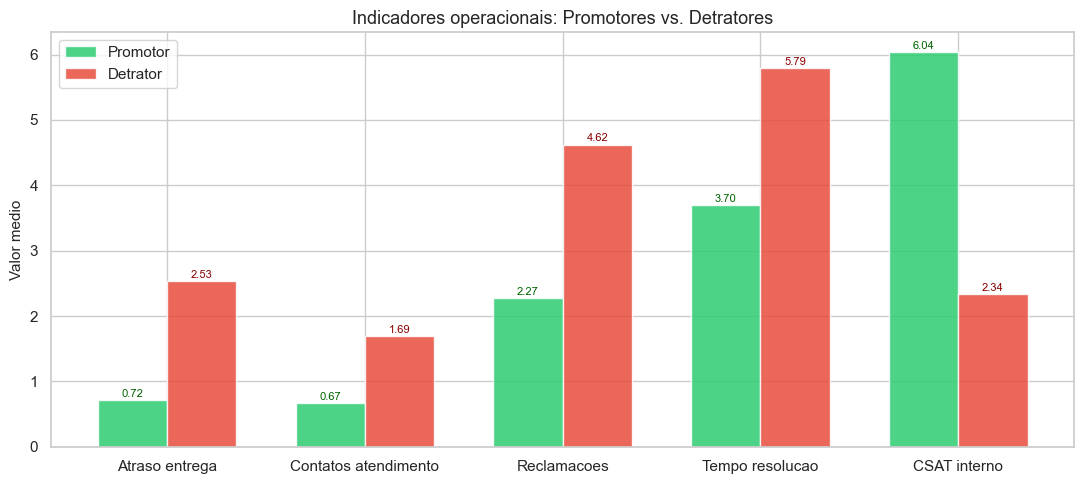

In [15]:
cols_perfil = ['delivery_delay_days', 'customer_service_contacts',
               'complaints_count', 'resolution_time_days', 'csat_internal_score']
labels_perfil = ['Atraso entrega', 'Contatos atendimento', 'Reclamacoes',
                 'Tempo resolucao', 'CSAT interno']

promo_vals = [df[df['nps_categoria']=='Promotor'][v].mean() for v in cols_perfil]
detrat_vals = [df[df['nps_categoria']=='Detrator'][v].mean() for v in cols_perfil]

x = range(len(labels_perfil))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - width/2 for i in x], promo_vals, width, label='Promotor', color='#2ecc71', alpha=0.85)
ax.bar([i + width/2 for i in x], detrat_vals, width, label='Detrator', color='#e74c3c', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(labels_perfil)
ax.set_ylabel('Valor medio')
ax.set_title('Indicadores operacionais: Promotores vs. Detratores')
ax.legend()
for i, (p, d) in enumerate(zip(promo_vals, detrat_vals)):
    ax.text(i - width/2, p + 0.05, f'{p:.2f}', ha='center', fontsize=8, color='darkgreen')
    ax.text(i + width/2, d + 0.05, f'{d:.2f}', ha='center', fontsize=8, color='darkred')
plt.tight_layout()
plt.savefig('../reports/fig_08_perfil_promotor_detrator.png', bbox_inches='tight', dpi=120)
plt.show()

## 11. Preparacao da Base Tratada

In [16]:
df.to_csv('../data/processed/nps_tratado.csv', index=False)
print(f'Base tratada salva: {df.shape[0]} linhas x {df.shape[1]} colunas')
print('Colunas adicionadas: nps_categoria, faixa_atraso')
print('Arquivo: data/processed/nps_tratado.csv')

Base tratada salva: 2500 linhas x 21 colunas
Colunas adicionadas: nps_categoria, faixa_atraso
Arquivo: data/processed/nps_tratado.csv


## 12. Sintese

A empresa esta com NPS bem negativo. Usando a definicao classica do NPS (notas 0-6 sao detratoras, 7-8 neutras e 9-10 promotoras), a base mostra cerca de 74% de detratores e apenas 4% de promotores, o que da um NPS agregado em torno de -69,6.

Olhando os dados, o fator que mais aparece ligado a satisfacao e o atraso na entrega. Pedidos no prazo tem nota media perto de 7, mas a partir de 3 dias de atraso a nota desaba para menos de 3. O tempo total de entrega em si nao mostrou correlacao com a nota, o que sugere que o problema esta em quebrar o prazo prometido, nao em demorar.

Reclamacoes e contatos com atendimento andam junto com a insatisfacao. Quem nunca precisou ligar para o atendimento tem nota media de 5,5; quem ligou cinco vezes, 2,2. Detratores acumulam em media mais reclamacoes que promotores.

A regiao geografica e o tempo de relacionamento com a empresa nao discriminaram bem entre satisfeitos e insatisfeitos nessa amostra. O problema parece ser operacional, e nao de perfil de cliente.

Sobre o impacto direto na receita: promotores recompraram em 30 dias em 100% dos casos, detratores em nenhum. Isso liga o NPS diretamente ao faturamento futuro.

Com esses padroes em maos, da para tentar prever quais clientes estao em risco de virar detratores antes da pesquisa ser enviada, usando justamente essas variaveis operacionais. E o que vou explorar no proximo notebook.